# Study 6 (prereg) ablations: literal listener & distance-blind null vs the full GP + RSA model

Two ablations of the full 4-D fit (`model-study6prereg-vbmc-laplace-beta.ipynb`), each refit to the
study 6 data with the same spec (Laplace + VBMC, fitted linking shapes, fitted beta, widened
beta bound, 2d embedding; fits produced by `fit_study6_ablation.py <which> prereg`):

- **no-transfer null**: EVERY condition loses its utterances — no channel from statements to
  the (unmentioned) test features, so predictions cannot differ by condition. This is the
  analog of the collaborator's base model ("reasoning about individuals and features only");
  per-feature variation survives via the profiled linking shapes. ls pinned, beta dropped
  (k=2: mu_0, sigma).
- **literal listener**: specific statements carry ZERO evidence (dropped from the utterance
  set; generics unchanged). Removes exactly the pragmatic "could have said the generic but
  chose not to" inference — its specific condition is geometrically identical to baseline.
- **distance-blind null**: length scale pinned at `LS_FLAT=10` (~13x the set1 cloud diameter,
  kernel effectively constant), 3 free params (mu_0, sigma, beta). Tests the GP feature-space
  component specifically; category-coherence reasoning and pragmatics stay intact. NOTE this is
  the study-9-style structure null, NOT the collaborator's "individuals only" base model.

All predictions below are **ratings-free** (coherence inferred from utterances only).

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")

import sys
sys.path.insert(0, ".")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax.numpy as jnp

import inference as inf
import studies68 as s68

inf.set_embed('2d')
RESULTS_DIR = os.path.join('results', 'study6prereg-ablations')
FULL_DIR    = os.path.join('results', 'study6prereg-vbmc-laplace-beta')

geom_full, responses_cond = s68.load_study6_prereg()
J, test_feature_names = geom_full['J'], geom_full['test_feature_names']
CONDS = list(responses_cond.keys())
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in CONDS}

geom_lit = s68.load_study6_prereg()[0]
geom_lit['x_train_cond']['specific'] = jnp.zeros((0, 2))
geom_lit['u_train_cond']['specific'] = jnp.zeros(0, dtype=jnp.int32)
geom_lit['train_names_cond']['specific'] = []

geom_nt = s68.load_study6_prereg()[0]
for c in list(geom_nt['x_train_cond']):
    geom_nt['x_train_cond'][c] = jnp.zeros((0, 2))
    geom_nt['u_train_cond'][c] = jnp.zeros(0, dtype=jnp.int32)
    geom_nt['train_names_cond'][c] = []

def load_fit(path):
    z = np.load(path, allow_pickle=True)
    fit = {k: z[k] for k in ('ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples')}
    fit.update(json.loads(str(z['meta'])))
    return fit

MODELS = {
    'null (no transfer)':    dict(fit=load_fit(os.path.join(RESULTS_DIR, 'posterior-notransfer.npz')),
                                  geom=geom_nt, n_params=2),
    'null (distance-blind)': dict(fit=load_fit(os.path.join(RESULTS_DIR, 'posterior-null.npz')),
                                  geom=geom_full, n_params=3),
    'literal listener':      dict(fit=load_fit(os.path.join(RESULTS_DIR, 'posterior-literal.npz')),
                                  geom=geom_lit, n_params=4),
    'full (pragmatic)':      dict(fit=load_fit(os.path.join(FULL_DIR, 'posterior-fitted-shapes.npz')),
                                  geom=geom_full, n_params=4),
}
for name, m in MODELS.items():
    print(f"{name:<22} convergence={m['fit']['convergence_status']}  "
          f"evals={m['fit']['func_count']}  ELBO={m['fit']['elbo']:.1f}")

load_study6_prereg: 446 of 471 rows kept after exclusions
load_study6_prereg: 446 of 471 rows kept after exclusions
load_study6_prereg: 446 of 471 rows kept after exclusions
null (no transfer)     convergence=probable  evals=100  ELBO=1899.5
null (distance-blind)  convergence=probable  evals=340  ELBO=1972.2
literal listener       convergence=probable  evals=280  ELBO=1966.9
full (pragmatic)       convergence=probable  evals=220  ELBO=1975.7


## Forward passes and comparison table

Each model's ratings-free predictions at its own posterior median, with its own profiled
linking shapes. `sum log Z` is the summed Laplace marginal likelihood at the median (plug-in,
no theta prior) — alongside the parameter counts it plays the AIC-ish role of the R pipeline's
`glmmTMB` comparison until the collaborator runs the real one on the exported CSVs.

In [2]:
results = {}
for name, m in MODELS.items():
    f = m['fit']
    ls, mu, sig, beta = (float(np.median(f['ls_samples'])), float(np.median(f['mu0_samples'])),
                         float(np.median(f['sigma_samples'])), float(np.median(f['beta_samples'])))
    ll, shapes, _ = inf.total_log_lik_free_shapes(m['geom'], responses_cond, ls, mu, sig,
                                                  beta_speaker=beta, return_shapes=True)
    mean_kl  = shapes[:, 0] / (shapes[:, 0] + shapes[:, 1])
    mean_nkl = shapes[:, 2] / (shapes[:, 2] + shapes[:, 3])
    pz1 = inf.prior_pz1_modes(m['geom'], ls, mu, sig, beta_speaker=beta)
    pred = {c: np.asarray(pz1[c]) * mean_kl + (1 - np.asarray(pz1[c])) * mean_nkl for c in CONDS}
    allp = np.concatenate([pred[c] for c in CONDS])
    alle = np.concatenate([emp_cond[c] for c in CONDS])
    results[name] = dict(theta=(ls, mu, sig, beta), ll=ll, pred=pred,
                         r2=np.corrcoef(allp, alle)[0, 1] ** 2)

print(f"{'model':<22}{'k':>3}{'ls':>8}{'mu_0':>8}{'sigma':>8}{'beta':>9}"
      f"{'sum logZ':>11}{'r2/feat':>9}")
for name, r in results.items():
    ls, mu, sig, beta = r['theta']
    print(f"{name:<22}{MODELS[name]['n_params']:>3}{ls:>8.2f}{mu:>8.2f}{sig:>8.2f}"
          f"{beta:>9.1f}{r['ll']:>11.1f}{r['r2']:>9.2f}")
print()
print(f"{'model':<22}" + ''.join(f"{c:>12}" for c in CONDS) + "   (predicted condition means)")
print(f"{'human':<22}" + ''.join(f"{float(np.array(responses_cond[c]).mean()):>12.3f}" for c in CONDS))
for name, r in results.items():
    print(f"{name:<22}" + ''.join(f"{r['pred'][c].mean():>12.3f}" for c in CONDS))

model                   k      ls    mu_0   sigma     beta   sum logZ  r2/feat
null (no transfer)      2   10.00   -0.03    5.66      3.0     1902.6     0.40
null (distance-blind)   3   10.00    0.16    2.73     30.0     1974.3     0.89
literal listener        4    1.92   -1.09    1.94     10.7     1969.8     0.83
full (pragmatic)        4    1.79    0.13    2.08     29.1     1980.3     0.90

model                      generic    specific    baseline   (predicted condition means)
human                        0.514       0.289       0.384
null (no transfer)           0.418       0.418       0.418
null (distance-blind)        0.539       0.288       0.437
literal listener             0.560       0.349       0.349
full (pragmatic)             0.538       0.289       0.434


## Three-panel model-vs-data figure (Exp-1a slide format)

Same visual language and progression as the collaborator's results slide — null (no transfer) |
literal | pragmatic — x = model prevalence, y = human prevalence, small dots = condition x
feature cells, large dots = condition means. The distance-blind null is deliberately NOT
plotted (it answers the orthogonal feature-geometry question and visually duplicates the full
model here); it remains in the comparison table above. The literal panel is the diagnostic
one: with specifics carrying no evidence, its blue (specific) mean must sit on top of the
green (baseline) mean on the model axis — the miss the pragmatic model fixes.

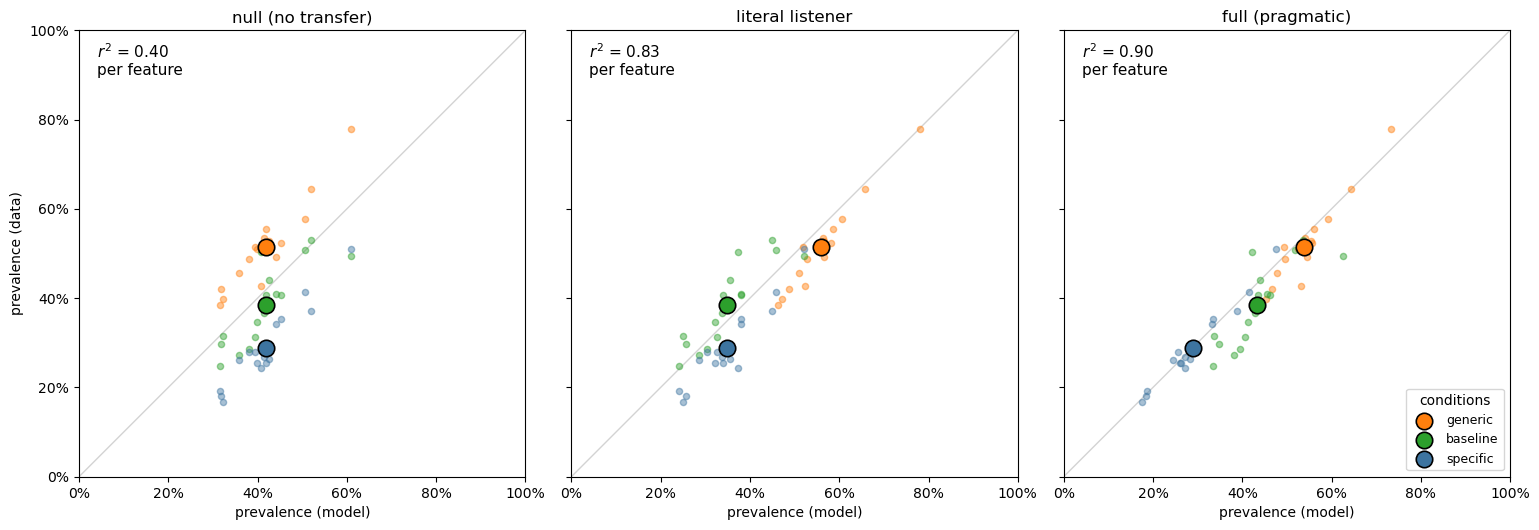

In [3]:
COND_ORDER = ['generic', 'baseline', 'specific']
COND_COLOR = {'generic': 'tab:orange', 'baseline': 'tab:green', 'specific': '#3d74a0'}
PLOT_MODELS = ['null (no transfer)', 'literal listener', 'full (pragmatic)']

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4), sharex=True, sharey=True)
for ax, name in zip(axes, PLOT_MODELS):
    r = results[name]
    ax.plot([0, 1], [0, 1], color='lightgray', lw=1, zorder=0)
    for c in COND_ORDER:
        ax.scatter(r['pred'][c], emp_cond[c], s=20, color=COND_COLOR[c], alpha=0.45, zorder=2)
        ax.scatter(r['pred'][c].mean(), emp_cond[c].mean(), s=140, color=COND_COLOR[c],
                   edgecolor='k', linewidth=1.2, zorder=3, label=c)
    ax.text(0.04, 0.90, f"$r^2$ = {r['r2']:.2f}\nper feature", transform=ax.transAxes, fontsize=11)
    ticks = np.linspace(0, 1, 6)
    ax.set_xticks(ticks); ax.set_xticklabels([f'{t:.0%}' for t in ticks])
    ax.set_yticks(ticks); ax.set_yticklabels([f'{t:.0%}' for t in ticks])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
    ax.set_xlabel('prevalence (model)'); ax.set_title(name)
axes[0].set_ylabel('prevalence (data)')
axes[-1].legend(title='conditions', fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

## Export for the R pipeline

Ablation predictions in the `df_prag_feature.csv` schema (condition, snake_case feature,
prevalence), written to `results/study6-ablations/` and `model/scratch/study 6/`, next to
the full model's `df_gp_feature.csv`.

In [4]:
col_of_feature = {v: k for k, v in s68.STUDY6_COL_TO_FEATURE.items()}
scratch_dir = os.path.join('..', 'scratch', 'study 6')
os.makedirs(scratch_dir, exist_ok=True)
for name, fname in [('null (no transfer)', 'df_gp_notransfer_feature_prereg.csv'),
                    ('null (distance-blind)', 'df_gp_null_feature_prereg.csv'),
                    ('literal listener', 'df_gp_lit_feature_prereg.csv')]:
    pred = results[name]['pred']
    export = pd.DataFrame([
        {'condition': c, 'feature': col_of_feature[f], 'prevalence': float(pred[c][j])}
        for c in COND_ORDER for j, f in enumerate(test_feature_names)])
    export.to_csv(os.path.join(RESULTS_DIR, fname), index=False)
    export.to_csv(os.path.join(scratch_dir, fname), index=False)
    print(f"saved {fname} to {RESULTS_DIR}/ and {scratch_dir}/")

saved df_gp_notransfer_feature_prereg.csv to results/study6prereg-ablations/ and ../scratch/study 6/
saved df_gp_null_feature_prereg.csv to results/study6prereg-ablations/ and ../scratch/study 6/
saved df_gp_lit_feature_prereg.csv to results/study6prereg-ablations/ and ../scratch/study 6/
